# 연속데이터예측_아이오와에임스지역_집값예측_train

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("./data/house_train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [5]:
(data.isna().sum()/len(data)*100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageFinish      5.547945
GarageYrBlt       5.547945
GarageType        5.547945
GarageCond        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtFinType1      2.534247
BsmtQual          2.534247
BsmtCond          2.534247
MasVnrArea        0.547945
Electrical        0.068493
1stFlrSF          0.000000
2ndFlrSF          0.000000
LowQualFinSF      0.000000
GrLivArea         0.000000
BsmtFullBath      0.000000
BsmtHalfBath      0.000000
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
KitchenAbvGr      0.000000
KitchenQual       0.000000
TotRmsAbvGrd      0.000000
Functional        0.000000
Fireplaces        0.000000
CentralAir        0.000000
GarageArea        0.000000
SalePrice         0.000000
Utilities         0.000000
L

In [6]:
data=data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], axis=1)

In [7]:
missing_cols=['LotFrontage','GarageQual','GarageType', 'GarageCond', 'BsmtExposure', 'BsmtFinType2',      
'BsmtFinType1' , 'BsmtQual', 'BsmtCond' , 'MasVnrArea' , 'Electrical' ]

In [8]:
for col in missing_cols:
    if data[col].dtype=='object':
        data[col]=data[col].fillna(data[col].mode()[0])
    else:
        data[col]=data[col].fillna(data[col].median())

In [9]:
(data.isna().sum()/len(data) *100).sort_values(ascending=False)

GarageYrBlt      5.547945
GarageFinish     5.547945
Functional       0.000000
TotRmsAbvGrd     0.000000
KitchenQual      0.000000
KitchenAbvGr     0.000000
BedroomAbvGr     0.000000
HalfBath         0.000000
Fireplaces       0.000000
BsmtHalfBath     0.000000
BsmtFullBath     0.000000
GrLivArea        0.000000
LowQualFinSF     0.000000
2ndFlrSF         0.000000
1stFlrSF         0.000000
Electrical       0.000000
CentralAir       0.000000
HeatingQC        0.000000
FullBath         0.000000
SaleCondition    0.000000
SaleType         0.000000
YrSold           0.000000
MoSold           0.000000
MiscVal          0.000000
PoolArea         0.000000
ScreenPorch      0.000000
3SsnPorch        0.000000
GarageType       0.000000
OpenPorchSF      0.000000
WoodDeckSF       0.000000
PavedDrive       0.000000
GarageCond       0.000000
GarageQual       0.000000
GarageArea       0.000000
GarageCars       0.000000
SalePrice        0.000000
EnclosedPorch    0.000000
OverallCond      0.000000
OverallQual 

이상값 탐지

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

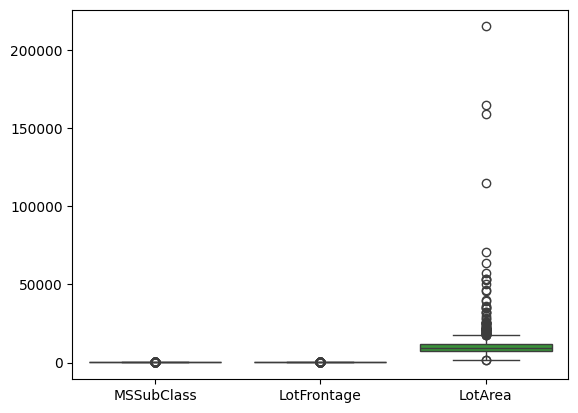

In [11]:
sns.boxplot(data.iloc[:, 1:5])

In [ ]:
sns.boxplot(data.iloc[:, 16:18])

In [ ]:
sns.boxplot(data.iloc[:, 19:25])

In [ ]:
data2=data.copy()
data3=data.copy()

In [ ]:
data.columns

In [ ]:
X=data.drop(['SalePrice','Id'], axis=1)
y=data['SalePrice']

In [ ]:
X=pd.get_dummies(X)

In [ ]:
X=X.astype('float32')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [ ]:
X_train, X_valid, y_train, y_valid=train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
rs=RobustScaler()
rs_X_train=rs.fit_transform(X_train)
rs_X_valid=rs.transform(X_valid)

In [ ]:
import joblib
joblib.dump(rs, "./model/iowa_rs.joblib")

# 출력층 Dense(1)

# model.compile(loss='mean_squared_error', metrics='mse')

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError

In [ ]:
inputs=Input(shape=(rs_X_train.shape[1],))
x=Dense(32, activation='relu')(inputs)
x=Dense(16, activation='relu')(x)
x=Dropout(0.3)(x)
outputs=Dense(1)(x)
base_model=Model(inputs=inputs, outputs=outputs)
base_model.summary()

In [ ]:
base_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path="./model/iowa_base_odel_best.keras"
check_point=ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
base_model_history=base_model.fit(rs_X_train, y_train, epochs=1000, batch_size=32, validation_data=(rs_X_valid, y_valid), callbacks=[early_stop, check_point], verbose=1)

In [ ]:
pred=base_model.predict(rs_X_valid)
pred=pd.DataFrame(pred, columns=['pred'])
pred

In [ ]:
y_valid=pd.DataFrame(y_valid)
y_valid_df=y_valid.reset_index(drop=True)
final_result=y_valid_df.join(pred)
final_result


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(base_model.evaluate(rs_X_valid, y_valid))

# 많은 컬럼 중에 어떤 컬럼을 선택? 266개
* 컬럼의 상관분석을 통해 타겟 변수와 상관도가 높은 컬럼만 선택
* 트리계열의 알고리즘을 사용해 분석 후 중요한 변수만 추출해서 재분석

In [ ]:
data2

In [ ]:
data2.info()

In [ ]:
data2.drop('Id', axis=1, inplace=True)

In [ ]:
data2=pd.get_dummies(data2)
data2.head

In [ ]:
corr_rate=data2.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

In [ ]:
new_cols1=corr_rate.head(15).index
new_cols1

In [ ]:
new_cols2=corr_rate.tail(4).index
new_cols2

In [ ]:
final_cols=list(new_cols1)+list(new_cols2)
final_cols

In [ ]:
final_df=data2[final_cols]

In [ ]:
final_df.corr(method='spearman')

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(final_df.corr(method='spearman'), annot=True, linewidths=1)

In [ ]:
ExterQual_TA - ExterQual_Gd -0.91
BsmtQual_TA - YearBuilt -0.7
BsmtQual_TA - YearBuilt 0.7
TotRmsAbvGrd - GrLivArea 0.83

In [ ]:
final_df=final_df.drop(['BsmtQual_TA', 'TotRmsAbvGrd','ExterQual_Gd'], axis=1)

In [ ]:
X2=final_df.drop('SalePrice', axis=1)
y2=final_df['SalePrice']

In [ ]:
X2

In [ ]:
X2_train, X2_valid, y2_train, y2_valid = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [ ]:
rs2=RobustScaler()
rs2_X2_train=rs2.fit_transform(X2_train)
rs2_X2_valid=rs2.transform(X2_valid)

In [ ]:
rs2_X2_train=rs2_X2_train.astype('float32')
rs2_X2_valid=rs2_X2_valid.aatype('float32')

In [ ]:
inputs=Input(shape=(rs2_X2_train.shape[1],))
x=Dense(32, activation='relu')(inputs)
x=Dense(16, activation='relu')(x)
x=Dropout(0.3)(x)
outputs=Dense(1)(x)
corr_select_model=Model(inputs=inputs, outputs=outputs)
corr_select_model.summary()

In [ ]:
corr_select_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path="./model/iowa_corr_select_model_best.keras"
check_point=ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
corr_select_model_history=corr_select_model.fit(rs2_X2_train, y2_train, epochs=1000, batch_size=32, 
                                               validation_data=(rs2_X2_valid, y2_valid),
                                               callbacks=[early_stop, check_point], verbose=1)

In [ ]:
pred=corr_select_model.predict(rs2_X2_valid)
pred=pd.DataFrame(pred, columns=['pred'])
pred

In [ ]:
y2_valid=pd.DataFrame(y2_valid)
y2_valid_df=y2_valid.reset_index(drop=True)
final_result=y2_valid_df.join(pred)
final_result